<a href="https://colab.research.google.com/github/DnlRKorn/histogram_for_sept26_hackathon/blob/main/make_hist_from_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This needs data available in ./parquet/*.parquet. If those files aren't available first run code in ./make_data.ipynb

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os
from pathlib import Path
import csv
import pyarrow.parquet as pq
import pandas as pd

In [64]:
!git clone https://github.com/DnlRKorn/histogram_for_sept26_hackathon

fatal: destination path 'histogram_for_sept26_hackathon' already exists and is not an empty directory.


In [65]:
def pruneOutliers(s:pd.Series,method:str) -> pd.Series:
    if(method=="Keep_Outliers"):return s
    elif(method=="IQR"):
        (q1,q3) = s.quantile([0.25,0.75])
        iqr = abs(q3-q1)
        low_bound = q1 - iqr * 1.5
        up_bound = q3 + iqr * 1.5
        return s[(s>=low_bound) & (s<=up_bound)]
    elif(method=="Z_Score_3stdevs"):
        z_score = s.to_frame().apply(stats.zscore, ddof=1).abs().iloc[:, 0]
        return s[z_score<=3]
    elif(method=="Z_Score_5stdevs"):
        z_score = s.to_frame().apply(stats.zscore, ddof=1).abs().iloc[:, 0]
        return s[z_score<=5]
    else:
        raise ValueError(f"No outlier method {method}")

def plotHistogram(prop_vals:pd.Series, bins, log_y:bool=False, chart_title=""):
    fig, ax = plt.subplots()
    ax.set_title(chart_title)
    ax.hist(prop_vals, bins=bins,log=log_y)

def getSeriesWithSPQOs(dataset,spqos):
    df = getDFForDataset(dataset)
    unique_spqos = sorted(list(set([x for x in df[["sub","pred","qual","obj"]].itertuples(index=False)])))
    valid_spqos = []
    for i,spqo_tup in enumerate(unique_spqos):
      if(i<len(spqos) and spqos[i]):valid_spqos.append(spqo_tup)
    filtered_df = df[df.apply(lambda x: (x["sub"],x["pred"],x["qual"],x["obj"]) in valid_spqos, axis=1)]
    return filtered_df.iloc[:,4]

def getSeriesForDataset(dataset,spqos=None):
    if(spqos!=None):
      return getSeriesWithSPQOs(dataset,spqos)
    pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    arr = pq_file.read(columns=[prop_name])
    return arr.to_pandas()[prop_name]

def getDFForDataset(dataset):
    pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    #print(pq_file.schema)
    arr = pq_file.read(columns=["sub","pred","qual","obj",prop_name])
    return arr.to_pandas()

def handleCategorical(dataset):
    s = getSeriesForDataset(dataset)
    if(s.dtype=="object"):
      return s.value_counts().reset_index()

def handleInputAndData(dataset,bin_cnt:int,log_bins:bool,log_y:bool, outlier_method:str,spqos=None):
    chart_title = " ".join(dataset.split('-'))

    prop_vals = getSeriesForDataset(dataset,spqos)
    prop_vals = pruneOutliers(prop_vals,outlier_method)
    if(log_bins):
        if(prop_vals.min()==0):min_val=0
        else:min_val = np.log10(prop_vals.min())
        bins = np.logspace(min_val,np.log10(prop_vals.max()),bin_cnt)
        print(bins)
    else: #No need to take the bins to log space, just let matplot handle the splitting
        bins = bin_cnt
    plotHistogram(prop_vals,bins,log_y,chart_title)

In [66]:
def addValuesToDf(spqo_df,dataset):
  big_df = getDFForDataset(dataset)
  if(big_df.iloc[:,4].dtype=="object"):
    spqo_df["min"] = np.nan()
    spqo_df["median"] = np.nan()
    spqo_df["max"] = np.nan()
    spqo_df["mean"] = np.nan()
    spqo_df["stdev"] = np.nan()
    return spqo_df

  def getSeriesFromBig(spqo):
      spqo = eval(spqo)
      return big_df[(big_df["sub"]==spqo[0]) & (big_df["pred"]==spqo[1]) & (big_df["qual"]==spqo[2]) & (big_df["obj"]==spqo[3])].iloc[:,4]
  spqo_series = [getSeriesFromBig(spqo) for spqo in spqo_df.spqo]
  spqo_df["min"] = [x.min() for x in spqo_series]
  spqo_df["median"] = [x.quantile(0.5) for x in spqo_series]
  spqo_df["max"] = [x.max() for x in spqo_series]
  spqo_df["mean"] = [x.mean() for x in spqo_series]
  spqo_df["stdev"] = [x.std() for x in spqo_series]
  return spqo_df

def getPresentAbsentCnts(dataset_name,calculate_extra_spqo_stats=False,spqos=None):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        dreader = csv.DictReader(f)
        for d in dreader:
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                s = getSeriesForDataset(dataset_name)
                max_val = s.max()
                min_val = s.min()
                print(f"Data summary for {ingest_name} {prop}\nMinimum Val:{min_val}\nMaximum Val:{max_val}\nPresent Cnt:{d["present_cnt"]}\nAbsent Cnt:{d["absent_cnt"]}")
    df = pd.read_csv(f"histogram_for_sept26_hackathon/data/seen_absent_indiv/{dataset_name}_cnts.csv")
    if(calculate_extra_spqo_stats): df = addValuesToDf(df,dataset_name)
    return df


Data summary for pubtator publications
Minimum Val:1
Maximum Val:27255
Present Cnt:10890003
Absent Cnt:0


,spqo,present_cnt,absent_cnt
0,"('chemical entity', 'causes', 'n/a', 'disease ...",674002,0
1,"('chemical entity', 'causes', 'n/a', 'gene or ...",10,0
2,"('chemical entity', 'negatively correlated wit...",519498,0
3,"('chemical entity', 'negatively correlated wit...",16,0
4,"('chemical entity', 'negatively correlated wit...",795196,0
5,"('chemical entity', 'pharmacologically interac...",5527,0
6,"('chemical entity', 'pharmacologically interac...",117,0
7,"('chemical entity', 'physically interacts with...",6350,0
8,"('chemical entity', 'physically interacts with...",3,0
9,"('chemical entity', 'physically interacts with...",20999,0


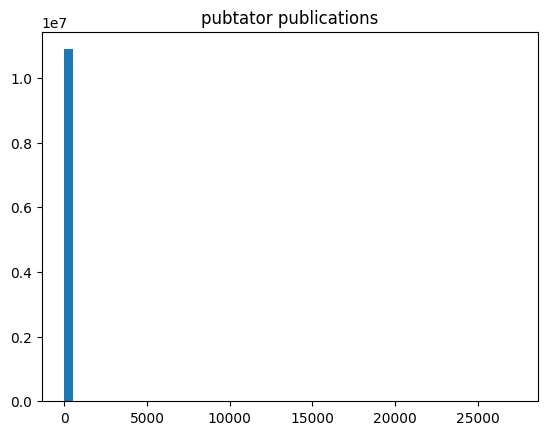

In [42]:
# @title User Input for Histogram Generation {single-column:true}
# @markdown Forms support many types of fields.

num_bins = 50 # @param {type: "number"}
log_bin_size = False # @param {type:"boolean"}
log_bin_height = False # @param {type:"boolean"}
calculate_extra_spqo_stats = False # @param {type:"boolean"}
prune_outlier_method = "Keep_Outliers" # @param ["Keep_Outliers","IQR","Z_Score_3stdevs","Z_Score_5stdevs"]
dataset = "pubtator-publications"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']
# @markdown ---

#print(dataset)
pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
handleInputAndData(dataset,num_bins,log_bin_size,log_bin_height,prune_outlier_method)
getPresentAbsentCnts(dataset,calculate_extra_spqo_stats)
#handleCategorical(dataset)

In [43]:
# @title Categorical Data {single-column:true}
# @markdown Forms support many types of fields.

dataset = "hpoa-has_evidence_of_type"  # @param ['gene2phenotype-gene2phenotype_confidence_category','goa-has_evidence_of_type','hpoa-has_evidence_of_type']
# @markdown ---

handleCategorical(dataset)

,has_evidence_of_type,count
0,['ECO:0000304'],134315
1,['ECO:0006017'],100088
2,['ECO:0000501'],27957


In [45]:
def getPrecentMissing(dataset_name):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        for d in csv.DictReader(f):
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                return (int(d["absent_cnt"])) / (int(d["present_cnt"])+int(d["absent_cnt"]))

def getStatsForSeries(s,source_name,prop_name):
    edge_type = str(s.dtype)
    metric = f"{prop_name} ({edge_type})"
    #print(x,dataset,edge_type,edge_type=="object")
    if(edge_type=="object"):edge_type="str"
    n = s.shape[0]
#    if(s.dtype=="object"):
#      s = s.apply(lambda x:x[0])
    percent_missing = getPrecentMissing(dataset)
    percent_zero = s[s==0].shape[0]/n
    unique_cnt = s.unique().shape[0]
    if(edge_type!="str"):
      (min, p1, p5, p10, p25, median, p75, p90, p95, p99, max) = s.quantile([0,0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])
      std = s.std()
      skew = s.skew()
      mean = s.mean()
    else:
      (min, p1, p5, p10, p25, median, p75, p90, p95, p99, max) = [None]*11
      std = None
      skew = None
      mean = None
    return (source_name,metric,n,percent_missing,min, p1, p5, p10, p25, median, p75, p90, p95, p99, max, percent_zero, unique_cnt,mean,std,skew)

In [46]:
# @title Big Table of Ingest/Prop Statistics For All Ingests (No individual SPQOs)

rows = []
for x in os.listdir("histogram_for_sept26_hackathon/data/parquet"):
  dataset = x.split(".")[0]
  source_name,prop_name = dataset.split('-')
  s = getSeriesForDataset(dataset)
  rows.append(getStatsForSeries(s,source_name,prop_name))
pd.DataFrame(rows,columns=["source","metric (edge_type)","n","percent_missing","min","p1"," 5"," p10","p25","median","p75","p90","p95","p99","max","percent_zero","unique_cnt","mean","std","skew"])

,source,metric (edge_type),n,percent_missing,min,p1,5,p10,p25,median,p75,p90,p95,p99,max,percent_zero,unique_cnt,mean,std,skew
0,chembl,has_confidence_score (float32),257106,0.046452,8.000000,8.000000,9.000000,9.000000,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,0.000000,2,8.962965e+00,1.887123e-01,-4.903060
1,go_cam,publications (int32),5011,0.238218,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,7.000000e+00,0.000000,7,1.192177e+00,5.453365e-01,3.866630
2,signor,has_confidence_score (float32),43625,0.000138,0.100000,0.200000,0.200000,0.200000,2.760000e-01,4.350000e-01,7.050000e-01,8.000000e-01,8.070000e-01,9.250000e-01,9.930000e-01,0.000000,754,4.823234e-01,2.274753e-01,0.313339
3,dakp,number_of_cases (int32),66315,0.120619,1.000000,1.000000,1.000000,1.000000,1.000000e+00,2.000000e+00,7.000000e+00,3.600000e+01,1.230000e+02,1.550860e+03,2.695720e+05,0.000000,1575,1.173594e+02,2.398859e+03,70.780633
4,bindingdb,publications (int32),1361214,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000,1,1.000000e+00,0.000000e+00,0.000000
5,gene2phenotype,gene2phenotype_confidence_category (object),3102,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN
6,goa,has_evidence_of_type (object),2135407,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,22,NaN,NaN,NaN
7,gtopdb,publications (int32),31883,0.115393,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,1.700000e+01,0.000000,14,1.281278e+00,8.502352e-01,4.962100
8,dgidb,dgidb_evidence_score (int32),41832,0.220599,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00,2.680000e+02,0.000000,70,1.665089e+00,3.591005e+00,38.983032
9,pubtator,publications (int32),10890003,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00,3.400000e+01,2.725500e+04,0.000000,1916,3.335690e+00,3.710550e+01,231.244335


In [47]:
# @title Make Table of Stats Broken Up By SPO
dataset = "diseases-diseases_confidence_score"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']

rows = []
#for x in os.listdir("histogram_for_sept26_hackathon/data/parquet"):
source_name,prop_name = dataset.split('-')
df = getDFForDataset(dataset)
for spo_grouped_pd in df.groupby(["sub","pred","obj"]):
  sub,pred,obj = spo_grouped_pd[0]
  s = spo_grouped_pd[1].iloc[:,4]
  (source_name,metric,n,percent_missing,min, p1, p5, p10, p25, median, p75, p90, p95, p99, max, percent_zero, unique_cnt,mean,std,skew) = getStatsForSeries(s,source_name,prop_name)
  rows.append([source_name,f"({sub},{pred},{obj})",sub,pred,obj,metric,n,percent_missing,min, p5, p25, median, p75, p95, max, percent_zero, unique_cnt,mean,std,skew])

pd.DataFrame(rows,columns=["source","SPO","sub","pred","obj","metric (edge_type)","n","percent_missing","min","p5","p25","median","p75","p95","max","percent_zero","unique_cnt","mean","std","skew"])

,source,SPO,sub,pred,obj,metric (edge_type),n,percent_missing,min,p5,p25,median,p75,p95,max,percent_zero,unique_cnt,mean,std,skew
0,diseases,"(gene or gene product,associated with,disease ...",gene or gene product,associated with,disease or phenotypic feature,diseases_confidence_score (float32),3917,0.0,2.0,5.0,5.0,5.0,5.0,5.0,5.0,0.0,4,4.936942,0.317769,-6.045211


In [ ]:

prop_vals = getSeriesForDataset(dataset)
outlier_method = "Keep_Outliers"
log_bins = True
prop_vals = pruneOutliers(prop_vals,outlier_method)
if(log_bins):
    if(prop_vals.min()==0):min_val=0
    else:min_val = np.log10(prop_vals.min())
    bins = np.logspace(min_val,np.log10(prop_vals.max()),20)

In [ ]:
bins

array([1.00000000e+00, 2.97635144e-01, 8.85866792e-02, 2.63665090e-02,
       7.84759973e-03, 2.33572148e-03, 6.95192799e-04, 2.06913809e-04,
       6.15848215e-05, 1.83298072e-05, 5.45559482e-06, 1.62377675e-06,
       4.83293028e-07, 1.43844990e-07, 4.28133244e-08, 1.27427500e-08,
       3.79269023e-09, 1.12883791e-09, 3.35981833e-10, 1.00000001e-10])

Data summary for signor has_confidence_score
Minimum Val:0.800000011920929
Maximum Val:0.800000011920929
Present Cnt:43625
Absent Cnt:6


,spqo,present_cnt,absent_cnt
0,"('chemical entity', 'affects', 'causes', 'gene...",2335,0
1,"('chemical entity', 'affects', 'n/a', 'chemica...",413,0
2,"('chemical entity', 'directly physically inter...",2259,0
3,"('chemical entity', 'directly physically inter...",411,0
4,"('gene or gene product', 'affects', 'causes', ...",72,0
5,"('gene or gene product', 'directly physically ...",72,0
6,"('gene or gene product', 'directly physically ...",17486,3
7,"('gene or gene product', 'regulates', 'causes'...",20577,3


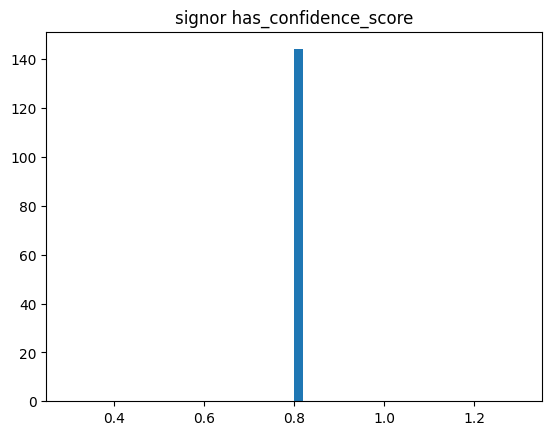

In [67]:
# @title User Input for Histogram Generation {single-column:true}
# @markdown Forms support many types of fields.

num_bins = 50 # @param {type: "number"}
log_bin_size = False # @param {type:"boolean"}
log_bin_height = False # @param {type:"boolean"}
calculate_extra_spqo_stats = False # @param {type:"boolean"}
prune_outlier_method = "Keep_Outliers" # @param ["Keep_Outliers","IQR","Z_Score_3stdevs","Z_Score_5stdevs"]
dataset = "signor-has_confidence_score"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']
# @markdown ---

#print(dataset)
spqo0 = False # @param {type:"boolean"}
spqo1 = False # @param {type:"boolean"}
spqo2 = False # @param {type:"boolean"}
spqo3 = False # @param {type:"boolean"}
spqo4 = True # @param {type:"boolean"}
spqo5 = True # @param {type:"boolean"}
spqo6 = False # @param {type:"boolean"}
spqo7 = False # @param {type:"boolean"}
spqo8 = False # @param {type:"boolean"}
spqo9 = False # @param {type:"boolean"}
spqo10 = False # @param {type:"boolean"}
spqo11 = False # @param {type:"boolean"}
spqo12 = False # @param {type:"boolean"}
spqo13 = False # @param {type:"boolean"}
spqo14 = False # @param {type:"boolean"}
spqo15 = False # @param {type:"boolean"}
spqo16 = False # @param {type:"boolean"}
spqo17 = False # @param {type:"boolean"}
spqo18 = False # @param {type:"boolean"}
spqo19 = False # @param {type:"boolean"}
spqo20 = False # @param {type:"boolean"}
spqo21 = False # @param {type:"boolean"}
spqo22 = False # @param {type:"boolean"}
spqo23 = False # @param {type:"boolean"}
spqo24 = False # @param {type:"boolean"}
spqo25 = False # @param {type:"boolean"}
spqo26 = False # @param {type:"boolean"}
spqo27 = False # @param {type:"boolean"}
spqo28 = False # @param {type:"boolean"}
spqo29 = False # @param {type:"boolean"}
spqo30 = False # @param {type:"boolean"}
spqo31 = False # @param {type:"boolean"}
spqo32 = False # @param {type:"boolean"}
spqo33 = False # @param {type:"boolean"}
spqo34 = False # @param {type:"boolean"}
spqo35 = False # @param {type:"boolean"}
spqo36 = False # @param {type:"boolean"}
spqo37 = False # @param {type:"boolean"}
spqo38 = False # @param {type:"boolean"}
spqo39 = False # @param {type:"boolean"}
spqos = [spqo0,spqo1,spqo2,spqo3,spqo4,spqo5,spqo6,spqo7,spqo8,spqo9,spqo10,spqo11,spqo12,spqo13,spqo14,spqo15,spqo16,spqo17,spqo18,spqo19,spqo20,spqo21,spqo22,spqo23,spqo24,spqo25,spqo26,spqo27,spqo28,spqo29,spqo30,spqo31,spqo32,spqo33,spqo34,spqo35,spqo36,spqo37,spqo38,spqo39]
pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
handleInputAndData(dataset,num_bins,log_bin_size,log_bin_height,prune_outlier_method,spqos)
getPresentAbsentCnts(dataset,calculate_extra_spqo_stats,spqos)
#handleCategorical(dataset)

In [31]:
l = []
for i in range(40):
  l.append(f"spqo{i}")
print(",".join(l))

spqo0,spqo1,spqo2,spqo3,spqo4,spqo5,spqo6,spqo7,spqo8,spqo9,spqo10,spqo11,spqo12,spqo13,spqo14,spqo15,spqo16,spqo17,spqo18,spqo19,spqo20,spqo21,spqo22,spqo23,spqo24,spqo25,spqo26,spqo27,spqo28,spqo29,spqo30,spqo31,spqo32,spqo33,spqo34,spqo35,spqo36,spqo37,spqo38,spqo39
